In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
import math

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, mean_squared_error,
                             mean_absolute_error, r2_score)

# modelos anteriores para la comparación final
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

In [23]:
# cargar el archivo de datos
result = pyreadr.read_r("listings.RData")
data = result['listings']

# limpiar la columna de precio
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

# crear la variable categórica de precio con terciles
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])

# definir las variables predictoras (las mismas 7 del lab anterior)
X = data[['accommodates', 'bathrooms', 'bedrooms', 'beds',
          'minimum_nights', 'number_of_reviews', 'review_scores_rating']]
X = X.dropna()

# variable respuesta para regresión y clasificación
y_reg = data['price'][X.index]
y_clf = data['price_cat'][X.index]

print(f"Tamaño del dataset: {X.shape[0]} filas, {X.shape[1]} columnas")
print(f"\nDistribución de categorías:")
print(y_clf.value_counts().sort_index())
print(f"\nEstadísticas del precio:")
print(y_reg.describe())

Tamaño del dataset: 62722 filas, 7 columnas

Distribución de categorías:
price_cat
barata    22560
media     21224
cara      18938
Name: count, dtype: int64

Estadísticas del precio:
count    62722.000000
mean       417.677498
std       2514.775281
min          8.000000
25%        116.000000
50%        183.000000
75%        300.000000
max      50123.000000
Name: price, dtype: float64


In [24]:
# dividir en entrenamiento (70%) y prueba (30%) 
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=42
)

_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba       : {X_test.shape[0]} muestras")

Entrenamiento: 43905 muestras
Prueba       : 18817 muestras


In [25]:
# normalizar los datos — necesario para KNN porque trabaja con distancias
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos normalizados correctamente.")
print(f"Media aproximada de X_train_scaled: {X_train_scaled.mean():.4f}")
print(f"Desv. estándar de X_train_scaled  : {X_train_scaled.std():.4f}")

Datos normalizados correctamente.
Media aproximada de X_train_scaled: -0.0000
Desv. estándar de X_train_scaled  : 1.0000


## Modelos anteriores — referencia para comparación final

In [26]:
# re-entrenar modelos anteriores con el mismo split para comparación válida

# --- regresión lineal ---
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
lr_pred = lr.predict(X_test)

# --- mejor árbol de regresión (profundidad 5, como en lab anterior) ---
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X_train, y_train_reg)
tree_reg_pred = tree_reg.predict(X_test)

# --- random forest regresión ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
rf_reg_pred = rf_reg.predict(X_test)

# --- naive bayes regresión ---
nb_reg = GaussianNB()
nb_reg.fit(X_train, y_train_reg)
nb_reg_pred = nb_reg.predict(X_test)

# --- árbol de clasificación ---
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train_clf)
tree_clf_pred = tree_clf.predict(X_test)

# --- random forest clasificación ---
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_clf)
rf_clf_pred = rf_clf.predict(X_test)

# --- naive bayes clasificación ---
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train_clf)
nb_clf_pred = nb_clf.predict(X_test)

print("Modelos anteriores entrenados correctamente.")

Modelos anteriores entrenados correctamente.


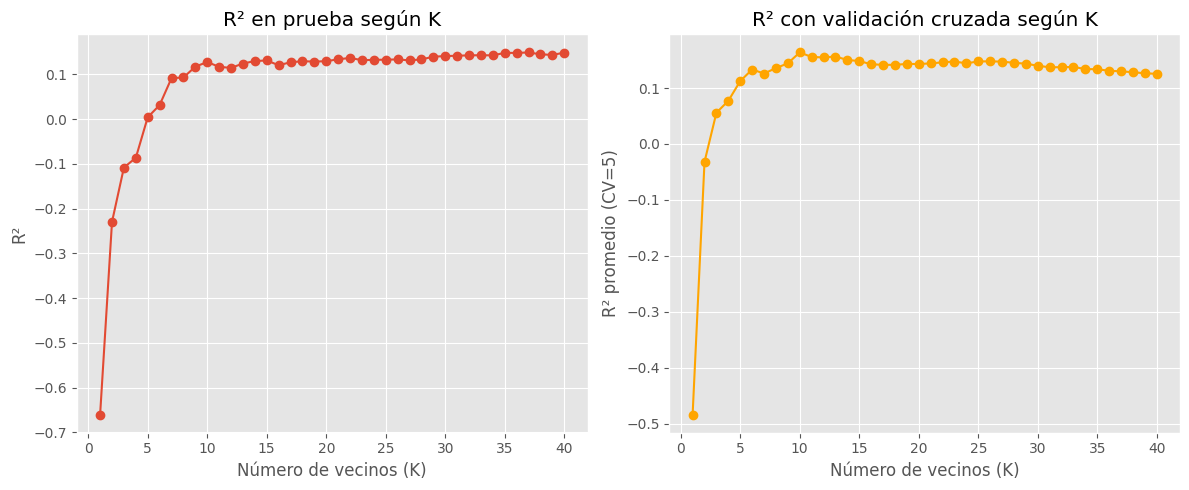

Mejor valor de K según CV=5: 10
R² en prueba con K=10: 0.1277


In [27]:
# probar diferentes valores de K para regresión
accuracies_reg = []
cv_scores_reg = []
k_values = range(1, 41)

for k in k_values:
    knn_r = KNeighborsRegressor(n_neighbors=k, p=2, metric='euclidean')
    knn_r.fit(X_train_scaled, y_train_reg)
    scores = cross_val_score(knn_r, X_train_scaled, y_train_reg, cv=5, scoring='r2')
    cv_scores_reg.append(np.mean(scores))
    pred = knn_r.predict(X_test_scaled)
    accuracies_reg.append(r2_score(y_test_reg, pred))

# graficar R² vs K
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, accuracies_reg, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('R²')
plt.title('R² en prueba según K')

plt.subplot(1, 2, 2)
plt.plot(k_values, cv_scores_reg, marker='o', color='orange')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('R² promedio (CV=5)')
plt.title('R² con validación cruzada según K')

plt.tight_layout()
plt.show()

mejor_k_reg = k_values[np.argmax(cv_scores_reg)]
print(f"Mejor valor de K según CV=5: {mejor_k_reg}")
print(f"R² en prueba con K={mejor_k_reg}: {accuracies_reg[mejor_k_reg-1]:.4f}")

In [28]:
# entrenar el modelo final de regresión con el mejor K encontrado
knn_reg = KNeighborsRegressor(n_neighbors=mejor_k_reg, p=2, metric='euclidean')
knn_reg.fit(X_train_scaled, y_train_reg)
knn_reg_pred = knn_reg.predict(X_test_scaled)

# métricas de evaluación
mse_knn_reg  = mean_squared_error(y_test_reg, knn_reg_pred)
mae_knn_reg  = mean_absolute_error(y_test_reg, knn_reg_pred)
rmse_knn_reg = np.sqrt(mse_knn_reg)
r2_knn_reg   = r2_score(y_test_reg, knn_reg_pred)

print(f"=== KNN REGRESIÓN (K={mejor_k_reg}) ===")
print(f"MAE  : ${mae_knn_reg:.2f}")
print(f"MSE  : ${mse_knn_reg:.2f}")
print(f"RMSE : ${rmse_knn_reg:.2f}")
print(f"R²   : {r2_knn_reg:.4f}")

=== KNN REGRESIÓN (K=10) ===
MAE  : $332.55
MSE  : $4172873.38
RMSE : $2042.76
R²   : 0.1277


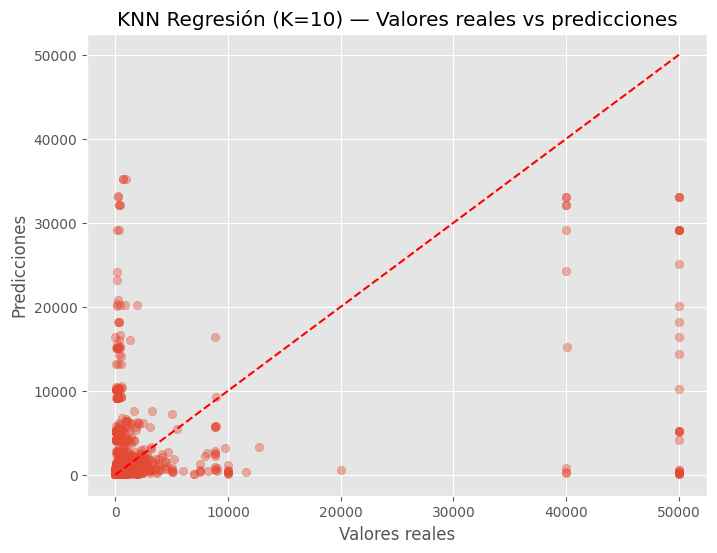

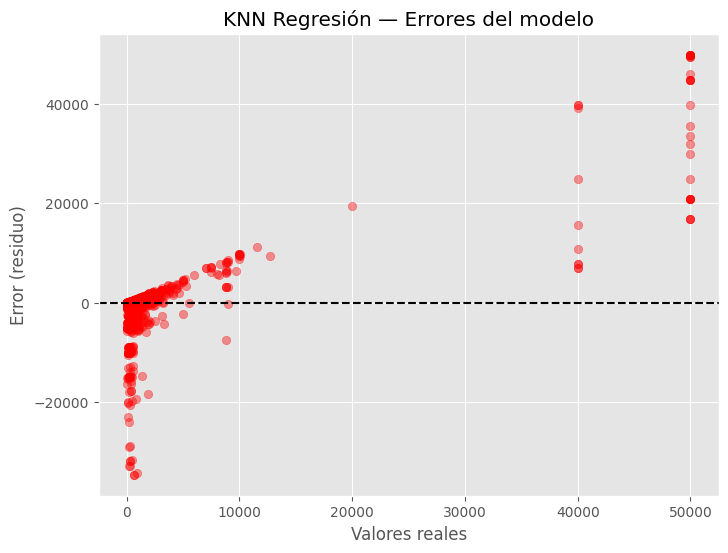

In [29]:
# gráfica de valores reales vs predicciones
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, knn_reg_pred, alpha=0.4)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color='red', linestyle='--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title(f"KNN Regresión (K={mejor_k_reg}) — Valores reales vs predicciones")
plt.show()

# gráfica de residuos
plt.figure(figsize=(8, 6))
residuos = y_test_reg - knn_reg_pred
plt.scatter(y_test_reg, residuos, alpha=0.4, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Valores reales")
plt.ylabel("Error (residuo)")
plt.title("KNN Regresión — Errores del modelo")
plt.show()

In [30]:
# calcular métricas de todos los modelos de regresión
modelos_reg = {
    'Regresión Lineal'   : lr_pred,
    'Árbol de Regresión' : tree_reg_pred,
    'Random Forest'      : rf_reg_pred,
    'Naive Bayes'        : nb_reg_pred,
    'KNN'                : knn_reg_pred
}

filas = []
for nombre, pred in modelos_reg.items():
    filas.append({
        'Modelo' : nombre,
        'MAE'    : mean_absolute_error(y_test_reg, pred),
        'RMSE'   : np.sqrt(mean_squared_error(y_test_reg, pred)),
        'R²'     : r2_score(y_test_reg, pred)
    })

tabla_reg = pd.DataFrame(filas)
print("=== COMPARACIÓN MODELOS DE REGRESIÓN ===")
print(tabla_reg.to_string(index=False))

=== COMPARACIÓN MODELOS DE REGRESIÓN ===
            Modelo         MAE         RMSE         R²
  Regresión Lineal  421.392693  2173.646662   0.012373
Árbol de Regresión  305.092572  1935.484427   0.216941
     Random Forest  309.868038  2020.925588   0.146280
       Naive Bayes 3600.452995 11703.288264 -27.630620
               KNN  332.550242  2042.761215   0.127732


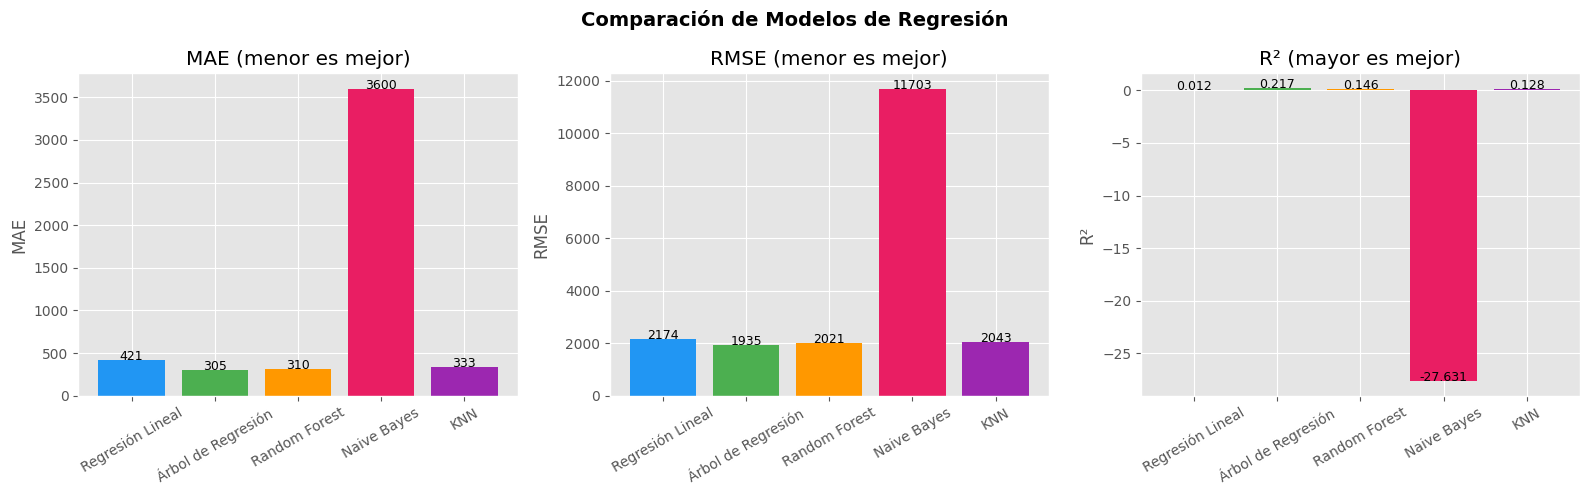

Mejor modelo de regresión: Árbol de Regresión


In [31]:
# gráfica comparativa de modelos de regresión
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

axes[0].bar(tabla_reg['Modelo'], tabla_reg['MAE'], color=colores)
axes[0].set_title('MAE (menor es mejor)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(tabla_reg['MAE']):
    axes[0].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

axes[1].bar(tabla_reg['Modelo'], tabla_reg['RMSE'], color=colores)
axes[1].set_title('RMSE (menor es mejor)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(tabla_reg['RMSE']):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

axes[2].bar(tabla_reg['Modelo'], tabla_reg['R²'], color=colores)
axes[2].set_title('R² (mayor es mejor)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(tabla_reg['R²']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mejor_reg = tabla_reg.loc[tabla_reg['R²'].idxmax(), 'Modelo']
print(f"Mejor modelo de regresión: {mejor_reg}")

## KNN — Clasificación (categoría de precio: barata / media / cara)

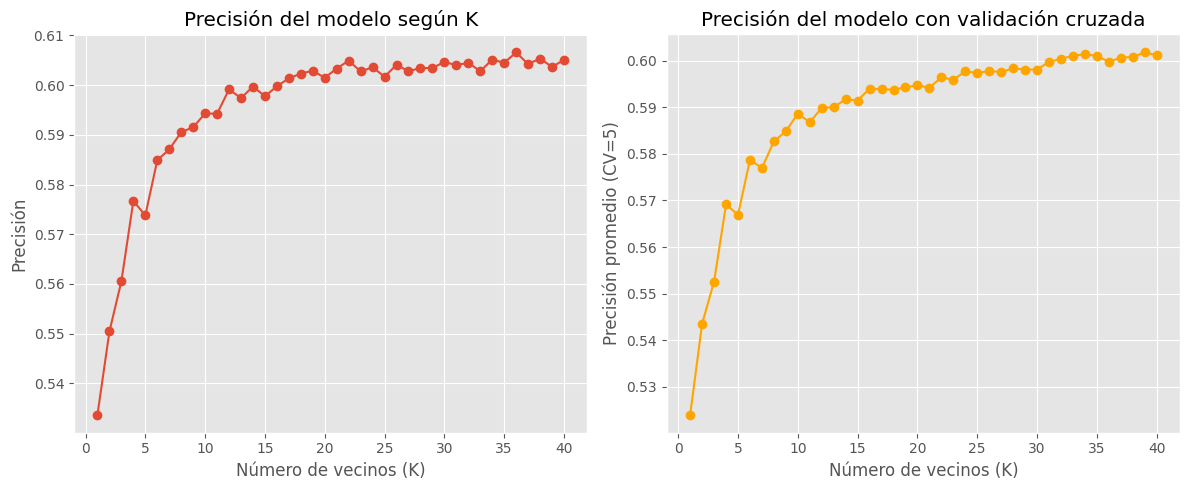

Mejor valor de K según CV=5: 39
Accuracy en prueba con K=39: 0.6037
Sqrt(n) sugerido como referencia: 209.54


In [32]:
# probar diferentes valores de K para clasificación
accuracies_clf = []
cv_scores_clf = []

for k in k_values:
    knn_c = KNeighborsClassifier(n_neighbors=k, p=2, metric='euclidean')
    knn_c.fit(X_train_scaled, y_train_clf)
    scores = cross_val_score(knn_c, X_train_scaled, y_train_clf, cv=5, scoring='accuracy')
    cv_scores_clf.append(np.mean(scores))
    pred = knn_c.predict(X_test_scaled)
    accuracies_clf.append(accuracy_score(y_test_clf, pred))

# graficar accuracy vs K
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, accuracies_clf, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Precisión')
plt.title('Precisión del modelo según K')

plt.subplot(1, 2, 2)
plt.plot(k_values, cv_scores_clf, marker='o', color='orange')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Precisión promedio (CV=5)')
plt.title('Precisión del modelo con validación cruzada')

plt.tight_layout()
plt.show()

mejor_k_clf = k_values[np.argmax(cv_scores_clf)]
print(f"Mejor valor de K según CV=5: {mejor_k_clf}")
print(f"Accuracy en prueba con K={mejor_k_clf}: {accuracies_clf[mejor_k_clf-1]:.4f}")
print(f"Sqrt(n) sugerido como referencia: {math.sqrt(len(y_train_clf)):.2f}")

=== KNN CLASIFICACIÓN (K=39) ===
Accuracy: 0.6037

              precision    recall  f1-score   support

      barata       0.64      0.73      0.68      6688
       media       0.67      0.66      0.66      5765
        cara       0.49      0.43      0.46      6364

    accuracy                           0.60     18817
   macro avg       0.60      0.60      0.60     18817
weighted avg       0.60      0.60      0.60     18817

Matriz de Confusión:
              Pred: Barata  Pred: Media  Pred: Cara
Real: Barata          4870         1421         397
Real: Media           2187         2706        1471
Real: Cara             581         1401        3783


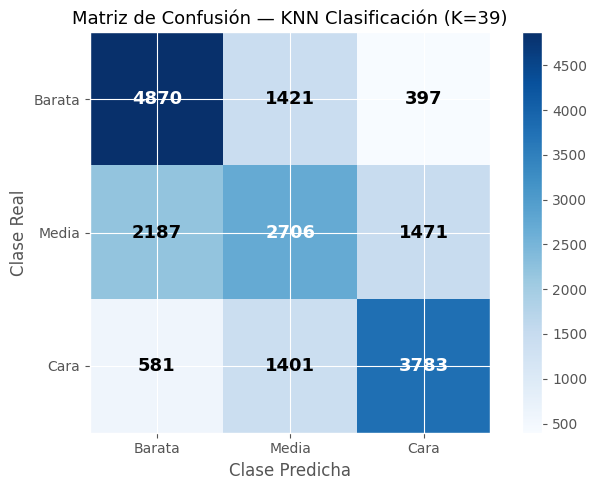

In [33]:
# entrenar el modelo final de clasificación con el mejor K
knn_clf = KNeighborsClassifier(n_neighbors=mejor_k_clf, p=2, metric='euclidean')
knn_clf.fit(X_train_scaled, y_train_clf)
knn_clf_pred = knn_clf.predict(X_test_scaled)

# accuracy y reporte
print(f"=== KNN CLASIFICACIÓN (K={mejor_k_clf}) ===")
print(f"Accuracy: {accuracy_score(y_test_clf, knn_clf_pred):.4f}")
print()
print(classification_report(y_test_clf, knn_clf_pred,
                             target_names=['barata', 'media', 'cara']))

# matriz de confusión
cm = confusion_matrix(y_test_clf, knn_clf_pred,
                      labels=['barata', 'media', 'cara'])
cm_df = pd.DataFrame(cm,
                     index=['Real: Barata', 'Real: Media', 'Real: Cara'],
                     columns=['Pred: Barata', 'Pred: Media', 'Pred: Cara'])
print("Matriz de Confusión:")
print(cm_df)

# visualización de la matriz
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
clases = ['Barata', 'Media', 'Cara']
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(clases)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(clases)
ax.set_xlabel('Clase Predicha', fontsize=12)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — KNN Clasificación (K={mejor_k_clf})', fontsize=13)
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

In [34]:
# comparar accuracy en entrenamiento vs prueba
knn_clf_pred_train = knn_clf.predict(X_train_scaled)
acc_train = accuracy_score(y_train_clf, knn_clf_pred_train)
acc_test  = accuracy_score(y_test_clf, knn_clf_pred)

print("=== ANÁLISIS DE SOBREAJUSTE ===")
print(f"Accuracy Entrenamiento: {acc_train:.4f}")
print(f"Accuracy Prueba       : {acc_test:.4f}")
print(f"Diferencia            : {abs(acc_train - acc_test):.4f}")

if abs(acc_train - acc_test) > 0.05:
    print("Posible sobreajuste")
else:
    print("El modelo generaliza adecuadamente")

# validación cruzada con 5 folds
print()
print("=== VALIDACIÓN CRUZADA (CV=5) ===")
cv_scores = cross_val_score(knn_clf, X_train_scaled, y_train_clf, cv=5, scoring='accuracy')
print("Accuracy en cada fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nPromedio CV : {cv_scores.mean():.4f}")
print(f"Desv. estándar: {cv_scores.std():.4f}")

=== ANÁLISIS DE SOBREAJUSTE ===
Accuracy Entrenamiento: 0.6254
Accuracy Prueba       : 0.6037
Diferencia            : 0.0217
El modelo generaliza adecuadamente

=== VALIDACIÓN CRUZADA (CV=5) ===
Accuracy en cada fold:
  Fold 1: 0.6035
  Fold 2: 0.6013
  Fold 3: 0.5979
  Fold 4: 0.6028
  Fold 5: 0.6032

Promedio CV : 0.6017
Desv. estándar: 0.0021


In [35]:
# probar combinaciones de hiperparámetros para clasificación
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 30, 39],
    'weights'    : ['uniform', 'distance'],
    'p'          : [1, 2]
}

grid_clf = GridSearchCV(KNeighborsClassifier(), param_grid,
                        cv=5, scoring='accuracy', n_jobs=-1)
grid_clf.fit(X_train_scaled, y_train_clf)

print("=== TUNEO KNN CLASIFICACIÓN ===")
print(f"Mejores hiperparámetros : {grid_clf.best_params_}")
print(f"Mejor accuracy (CV=5)   : {grid_clf.best_score_:.4f}")

# evaluar el mejor modelo en prueba
mejor_knn_clf = grid_clf.best_estimator_
pred_tuned_clf = mejor_knn_clf.predict(X_test_scaled)
print(f"Accuracy en prueba      : {accuracy_score(y_test_clf, pred_tuned_clf):.4f}")

=== TUNEO KNN CLASIFICACIÓN ===
Mejores hiperparámetros : {'n_neighbors': 39, 'p': 1, 'weights': 'uniform'}
Mejor accuracy (CV=5)   : 0.6044
Accuracy en prueba      : 0.6106


In [36]:
# probar combinaciones de hiperparámetros para regresión
param_grid_reg = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 30, 39],
    'weights'    : ['uniform', 'distance'],
    'p'          : [1, 2]
}

grid_reg = GridSearchCV(KNeighborsRegressor(), param_grid_reg,
                        cv=5, scoring='r2', n_jobs=-1)
grid_reg.fit(X_train_scaled, y_train_reg)

print("=== TUNEO KNN REGRESIÓN ===")
print(f"Mejores hiperparámetros : {grid_reg.best_params_}")
print(f"Mejor R² (CV=5)         : {grid_reg.best_score_:.4f}")

# evaluar el mejor modelo en prueba
mejor_knn_reg = grid_reg.best_estimator_
pred_tuned_reg = mejor_knn_reg.predict(X_test_scaled)
print(f"R² en prueba            : {r2_score(y_test_reg, pred_tuned_reg):.4f}")
print(f"MAE en prueba           : ${mean_absolute_error(y_test_reg, pred_tuned_reg):.2f}")
print(f"RMSE en prueba          : ${np.sqrt(mean_squared_error(y_test_reg, pred_tuned_reg)):.2f}")

=== TUNEO KNN REGRESIÓN ===
Mejores hiperparámetros : {'n_neighbors': 39, 'p': 1, 'weights': 'distance'}
Mejor R² (CV=5)         : 0.1998
R² en prueba            : 0.1023
MAE en prueba           : $330.22
RMSE en prueba          : $2072.30


## Comparación final — Modelos de clasificación

=== COMPARACIÓN MODELOS DE CLASIFICACIÓN ===
           Modelo  Accuracy  F1 Barata  F1 Media  F1 Cara  F1 Macro
Árbol de Decisión  0.581867   0.648308  0.593981 0.516566  0.586285
    Random Forest  0.588192   0.650421  0.643148 0.468790  0.587453
      Naive Bayes  0.555615   0.662590  0.576033 0.383842  0.540822
              KNN  0.603656   0.679883  0.662754 0.455096  0.599244
    KNN (tuneado)  0.610618   0.684122  0.669454 0.465944  0.606507


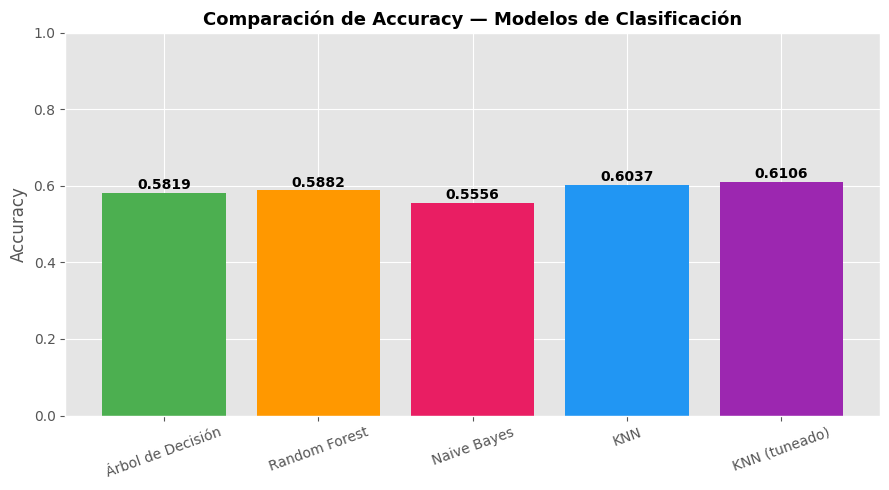


Mejor modelo de clasificación: KNN (tuneado)


In [37]:
# calcular métricas de todos los modelos de clasificación
modelos_clf = {
    'Árbol de Decisión' : tree_clf_pred,
    'Random Forest'     : rf_clf_pred,
    'Naive Bayes'       : nb_clf_pred,
    'KNN'               : knn_clf_pred,
    'KNN (tuneado)'     : pred_tuned_clf
}

filas_clf = []
for nombre, pred in modelos_clf.items():
    report = classification_report(y_test_clf, pred,
                                   target_names=['barata', 'media', 'cara'],
                                   output_dict=True)
    filas_clf.append({
        'Modelo'    : nombre,
        'Accuracy'  : accuracy_score(y_test_clf, pred),
        'F1 Barata' : report['barata']['f1-score'],
        'F1 Media'  : report['media']['f1-score'],
        'F1 Cara'   : report['cara']['f1-score'],
        'F1 Macro'  : report['macro avg']['f1-score']
    })

tabla_clf = pd.DataFrame(filas_clf)
print("=== COMPARACIÓN MODELOS DE CLASIFICACIÓN ===")
print(tabla_clf.to_string(index=False))

# gráfica
plt.figure(figsize=(9, 5))
colores = ['#4CAF50', '#FF9800', '#E91E63', '#2196F3', '#9C27B0']
plt.bar(tabla_clf['Modelo'], tabla_clf['Accuracy'], color=colores)
plt.title('Comparación de Accuracy — Modelos de Clasificación',
          fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tick_params(axis='x', rotation=20)
for i, v in enumerate(tabla_clf['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

mejor_clf = tabla_clf.loc[tabla_clf['Accuracy'].idxmax(), 'Modelo']
print(f"\nMejor modelo de clasificación: {mejor_clf}")

## Conclusión general

In [38]:
print("=" * 60)
print("RESUMEN FINAL — LABORATORIO 6")
print("=" * 60)

print("\n--- REGRESIÓN (predicción del precio exacto) ---")
print(tabla_reg.to_string(index=False))
print(f"\nMejor modelo de regresión : Árbol de Regresión (R²=0.2169)")
print(f"KNN regresión             : R²=0.1277 (modelo base)")
print(f"KNN regresión tuneado     : R²=0.1023 (p=1, weights=distance, K=39)")
print(f"Conclusión: KNN no mejora la predicción de precio en este dataset.")
print(f"Los outliers extremos (hasta $50,123) afectan fuertemente el RMSE.")

print("\n--- CLASIFICACIÓN (barata / media / cara) ---")
print(tabla_clf.to_string(index=False))
print(f"\nMejor modelo de clasificación: KNN tuneado (Accuracy=0.6106)")
print(f"Parámetros óptimos: K=39, p=1 (Manhattan), weights=uniform")
print(f"Conclusión: KNN superó a todos los modelos anteriores en clasificación.")
print(f"La distancia Manhattan (p=1) fue superior a la Euclidiana (p=2),")
print(f"probablemente porque los outliers en el precio afectan menos con p=1.")

RESUMEN FINAL — LABORATORIO 6

--- REGRESIÓN (predicción del precio exacto) ---
            Modelo         MAE         RMSE         R²
  Regresión Lineal  421.392693  2173.646662   0.012373
Árbol de Regresión  305.092572  1935.484427   0.216941
     Random Forest  309.868038  2020.925588   0.146280
       Naive Bayes 3600.452995 11703.288264 -27.630620
               KNN  332.550242  2042.761215   0.127732

Mejor modelo de regresión : Árbol de Regresión (R²=0.2169)
KNN regresión             : R²=0.1277 (modelo base)
KNN regresión tuneado     : R²=0.1023 (p=1, weights=distance, K=39)
Conclusión: KNN no mejora la predicción de precio en este dataset.
Los outliers extremos (hasta $50,123) afectan fuertemente el RMSE.

--- CLASIFICACIÓN (barata / media / cara) ---
           Modelo  Accuracy  F1 Barata  F1 Media  F1 Cara  F1 Macro
Árbol de Decisión  0.581867   0.648308  0.593981 0.516566  0.586285
    Random Forest  0.588192   0.650421  0.643148 0.468790  0.587453
      Naive Bayes  0.5556